In [5]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# get necessary packages
!python -m pip install paddlepaddle-gpu -i https://pypi.tuna.tsinghua.edu.cn/simple
!pip install "paddleocr==2.7.3"

In [ ]:
!pip install "numpy<2.0.0"

In [ ]:
!pip install langchain langchain-community

In [ ]:
!wget -q -O font.ttf https://raw.githubusercontent.com/PaddlePaddle/PaddleOCR/release/2.7/doc/fonts/latin.ttf

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
from PIL import Image

#Load image

In [ ]:
from pathlib import Path

BASE_PATH = Path(r"C:\Users\Admin\sroie-ocr-ie")
test_path = BASE_PATH / "data" / "test" / "img"

In [ ]:
img_test = cv2.imread(str(test_path / "000.jpg"))
plt.figure(figsize=(10, 10))
plt.imshow(img_test)
plt.axis('off')
plt.show()

#Preprocessing

In [ ]:
def preprocess_img(img_path):
  img = cv2.imread(img_path)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)) #Contrast Limited Adaptive Histogram Equalization
  enhance_img = clahe.apply(gray)
  res = cv2.GaussianBlur(enhance_img,(3,3),0) # Denoising with kernel (3,3)
  return res

# PaddleOCR

In [ ]:
from paddleocr import PaddleOCR,draw_ocr

ocr_model = PaddleOCR(use_gpu = False,use_angle_cls=True, lang='en')

In [ ]:
def ocr_image(img_path, conf_threshold = 0.6):
  processed_image = preprocess_img(img_path)
  res = ocr_model.ocr(processed_image,cls = True)
  lines = []

  for line in res[0]:
    bbox, (text, confidence) = line
    if confidence >= conf_threshold:
      lines.append({
            "text": text,
            "bbox": bbox,
            "confidence": confidence
        })
    sorted_line = sorted(lines, key=lambda x: (x["bbox"][0][1], x["bbox"][0][0]))
    boxes = [item["bbox"] for item in sorted_line]
  return sorted_line, boxes

In [ ]:
def draw_image(img_path, boxes, output_path=None):
    image = Image.open(img_path).convert('RGB')
    im_show = draw_ocr(image, boxes, font_path='font.ttf')
    im_show = Image.fromarray(im_show)
    if output_path is not None:
        im_show.save(output_path)
        print(f"Saved image at: {output_path}")


In [ ]:
import json

def save_to_json(data, output_json_path):
    with open(output_json_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=4)
    print(f"Saved at: {output_json_path}")

In [ ]:
import glob

def process_folder(input_dir, output_dir_images, output_dir_json, conf_threshold=0.6):
    os.makedirs(output_dir_images, exist_ok=True)
    os.makedirs(output_dir_json, exist_ok=True)

    list_file = glob.glob(os.path.join(input_dir, '*.*'))
    print(f'Number of files: {len(list_file)}')

    count = 0

    for img_path in list_file:
        if not img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        base_name = os.path.splitext(os.path.basename(img_path))[0]

        out_img_path = os.path.join(output_dir_images, f"{base_name}_result.jpg")
        out_json_path = os.path.join(output_dir_json, f"{base_name}.json")

        try:
            sorted_line, boxes = ocr_image(img_path, conf_threshold)
            draw_image(img_path, boxes, out_img_path)
            save_to_json(sorted_line, out_json_path)

            count += 1
            print(f"Saved")

        except Exception as e:
            print(f"   Error '{base_name}': {e}")

    print(f"Saved {count}.")

In [ ]:
test_path = '/content/sroie-ocr-ie/data/test/img'
Img_path = '/content/drive/MyDrive/CV/Data/Images'
Text_path = '/content/drive/MyDrive/CV/Data/Text'
process_folder(test_path, Img_path, Text_path)

# Draw

[2026/03/06 19:19:30] ppocr DEBUG: dt_boxes num : 45, elapsed : 0.24108242988586426
[2026/03/06 19:19:30] ppocr DEBUG: cls num  : 45, elapsed : 0.17048072814941406
[2026/03/06 19:19:34] ppocr DEBUG: rec_res num  : 45, elapsed : 4.177119016647339


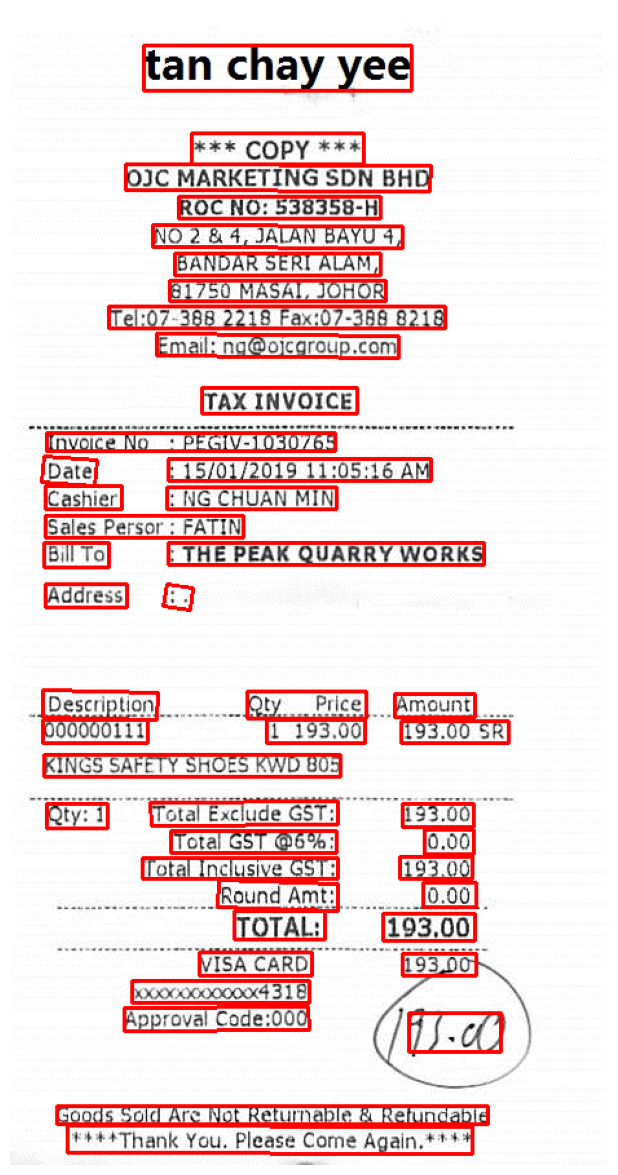

In [44]:
image = Image.open(os.path.join(test_path, '000.jpg')).convert('RGB')
_, box = ocr_image(os.path.join(test_path, '000.jpg'))
im_show = draw_ocr(image, box, font_path='font.ttf')

im_show = Image.fromarray(im_show)

plt.figure(figsize=(15, 15))
plt.imshow(im_show)
plt.axis('off')
plt.show()